In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph,START,END
from loguru import logger


#1. 构建子图
#1.1 声明子图的状态
class SubgraphState(TypedDict):
    raw_text:str #未清洗的文本
    stripped_text:str # 去除首尾的空格
    punctuated_text:str # 句尾添加句号

#1.2 声明子图的节点 -> 去除空格的节点
def subgraph_strip_node(state:SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()
    logger.info("调用子图中的strip节点")
    return {
        "stripped_text":stripped_text
    }

#1.3 添加句号的节点
def subgraph_punctuated_node(state:SubgraphState) -> SubgraphState:
    stripped_text = state["stripped_text"]
    punctuated_text = stripped_text + '。'
    logger.info("调用子图中的punctuated节点")
    return {
        "punctuated_text":punctuated_text
    }

#1.4 构建子图
builder = StateGraph(state_schema=SubgraphState)
builder.add_node("subgraph_strip_node",subgraph_strip_node)
builder.add_node("subgraph_punctuated_node",subgraph_punctuated_node)
builder.add_edge(START,"subgraph_strip_node")
builder.add_edge("subgraph_strip_node","subgraph_punctuated_node")
builder.add_edge("subgraph_punctuated_node",END)
subgraph = builder.compile()

res = subgraph.invoke({
    "raw_text":"   langgraph真有意思   "
})
print(res)



2026-08-15 16:01:00.630 | INFO     | __main__:subgraph_strip_node:18 - 调用子图中的strip节点
2026-08-15 16:01:00.630 | INFO     | __main__:subgraph_punctuated_node:27 - 调用子图中的punctuated节点


{'raw_text': '   langgraph真有意思   ', 'stripped_text': 'langgraph真有意思', 'punctuated_text': 'langgraph真有意思。'}


In [3]:
#2.构建父图
#2.1 声明状态
class ParentState(TypedDict):
    input_text:str
    cleaned_text:str

#2.2 声明节点 => 调用子图节点
def call_subgraph(state:ParentState)->ParentState:
    input_text = state["input_text"]
    res = subgraph.invoke({"raw_text":input_text})
    cleaned_text = res["punctuated_text"]
    return {
        "cleaned_text":cleaned_text
    }

#2.3 构建父图
parent_builder = StateGraph(state_schema=ParentState)
parent_builder.add_node("call_subgraph",call_subgraph)
parent_builder.add_edge(START,"call_subgraph")
parent_builder.add_edge("call_subgraph",END)

parent_graph = parent_builder.compile()

#2.4 调用父图 => 内部函数会调用子图
res = parent_graph.invoke({"input_text":"    langgraph真好玩   "})
print(res)

2026-08-15 16:01:17.849 | INFO     | __main__:subgraph_strip_node:18 - 调用子图中的strip节点
2026-08-15 16:01:17.850 | INFO     | __main__:subgraph_punctuated_node:27 - 调用子图中的punctuated节点


{'input_text': '    langgraph真好玩   ', 'cleaned_text': 'langgraph真好玩。'}


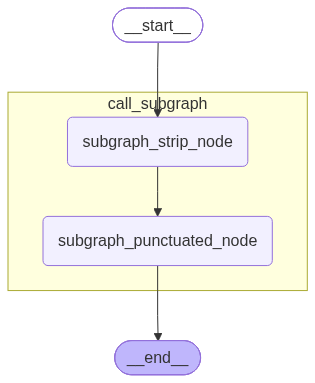

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	__end__([<p>__end__</p>]):::last
	__start__ --> call_subgraph\3asubgraph_strip_node;
	call_subgraph\3asubgraph_punctuated_node --> __end__;
	subgraph call_subgraph
	call_subgraph\3asubgraph_strip_node(subgraph_strip_node)
	call_subgraph\3asubgraph_punctuated_node(subgraph_punctuated_node)
	call_subgraph\3asubgraph_strip_node --> call_subgraph\3asubgraph_punctuated_node;
	end
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [4]:
from IPython.display import display,Image
display(
    Image(parent_graph.get_graph(xray=True).draw_mermaid_png())
)

raw_mermaid = parent_graph.get_graph(xray=True).draw_mermaid()
print(raw_mermaid)

In [15]:
list(parent_graph.get_subgraphs())

[('call_subgraph',
  <langgraph.graph.state.CompiledStateGraph at 0x1e46b3bf5c0>)]